In [1]:
# This file includes visualization codes for our preprint paper:  
# Hydroclimate reshapes land carbon storage estimates through lateral organic carbon loss
# This file shows the implementation process of our physically constrained multi-task LSTM model and visualization of main figures.

#Copyright (c) 2025 Shengyue Chen. All rights reserved.
#You should have received a copy of the MIT license along with the code. If not,
#see <https://opensource.org/licenses/MIT>

In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
import os
import numpy as np
from numpy import ma 
import pandas as pd
import xarray as xr
import ultraplot as uplt
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize,ListedColormap,BoundaryNorm,LinearSegmentedColormap
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
from scipy.interpolate import interp1d

In [4]:
filepath = os.getcwd()

In [5]:
# Visualization of the main figures
font_large=12
font_small=11
uplt_dict = {
    'tick.len': 2,
    'tick.dir': 'in',
    'font.largesize': font_large,
    'font.smallsize': font_small,
    'pdf.fonttype': 42,  
    'ps.fonttype': 42, 
    'text.color': 'black',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1, 
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'black',
    'legend.labelcolor': 'black',
    'lines.color': 'black',
}
uplt.rc.style='seaborn-v0_8-paper'
uplt.rc.update(uplt_dict)

In [6]:
# load data
grid_mean = pd.read_csv(os.path.join(filepath, 'grid_mean.csv'))

In [7]:
# CustomNormalize extends matplotlib.colors.Normalize to 
# allow non-linear normalization of data values based on specified levels
class CustomNormalize(Normalize):
    def __init__(self, values, levels, clip=False):
        super().__init__(vmin=min(values), vmax=max(values), clip=clip)
        self._interp = interp1d(values, levels, bounds_error=False, fill_value=(0, 1))

    def __call__(self, value, clip=None):
        val = ma.asarray(value)
        result = self._interp(val.data)
        return ma.array(result, mask=val.mask)

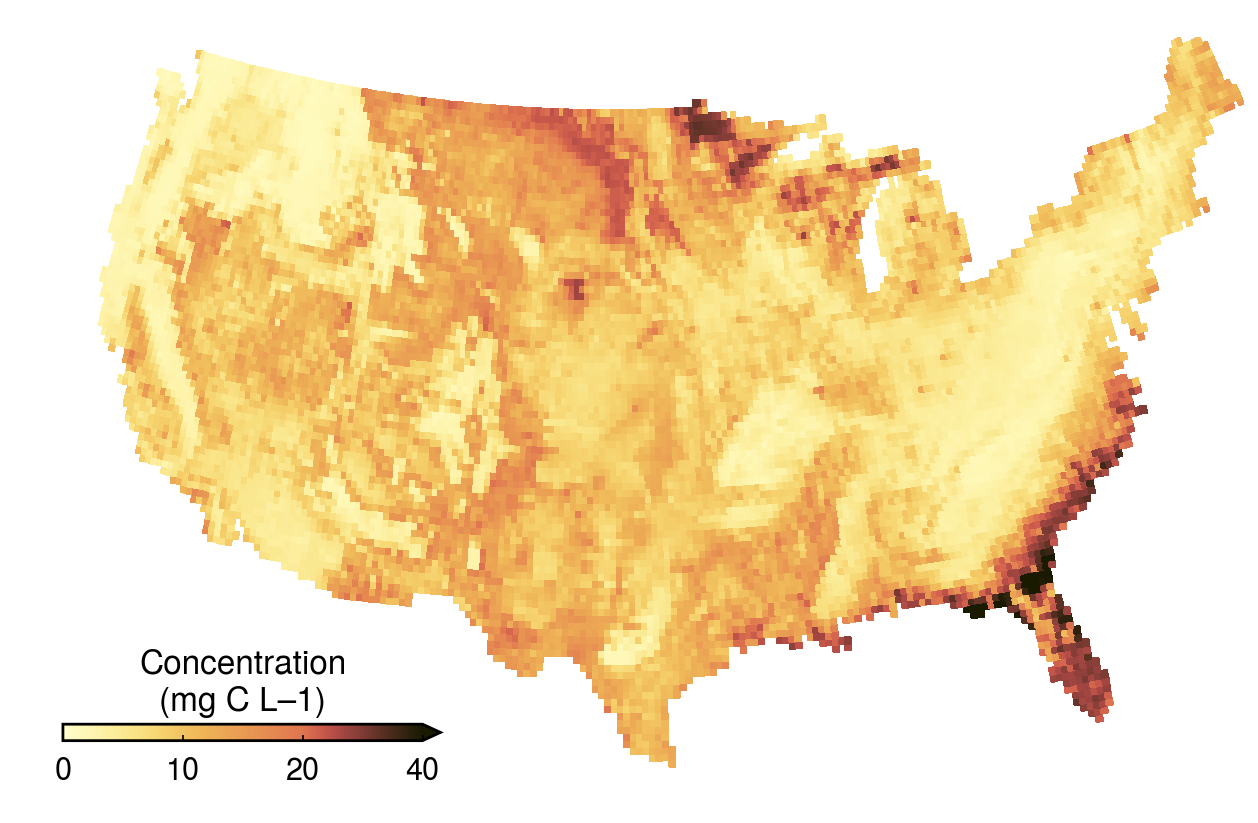

In [8]:
# grid-scale TOC concentration map
def plot_grid_toc_concentration(df_grid):
    df_pivot = df_grid.pivot(index='latitude', columns='longitude', values='C_TOC')
    da = xr.DataArray(df_pivot.values,
                      coords={"latitude": df_pivot.index.values, 
                              "longitude": df_pivot.columns.values},
                      dims=["latitude", "longitude"])
    coordination1 = 2163
    lonlim = (-122, -75)
    latlim = (25, 50)

    fig = uplt.figure(refwidth=6, share=False, span=False, tight=True)
    ax = fig.add_subplot(projection=ccrs.epsg(coordination1))

    cbar_tick = [0, 10, 20, 40]
    norm = CustomNormalize(cbar_tick, np.linspace(0, 1, len(cbar_tick)))
    im = ax.pcolormesh(da.longitude,da.latitude,da.values,cmap='lajolla',discrete=False,norm=norm)

    cax = fig.add_axes([0.05, 0.1, 0.3, 0.02], title='Concentration\n(mg C L–1)')
    fig.colorbar(im,cax=cax,orientation='horizontal',extend='max',ticks=cbar_tick)

    ax.format(lonlim=lonlim, latlim=latlim, linewidth=0)
    
plot_grid_toc_concentration(grid_mean)

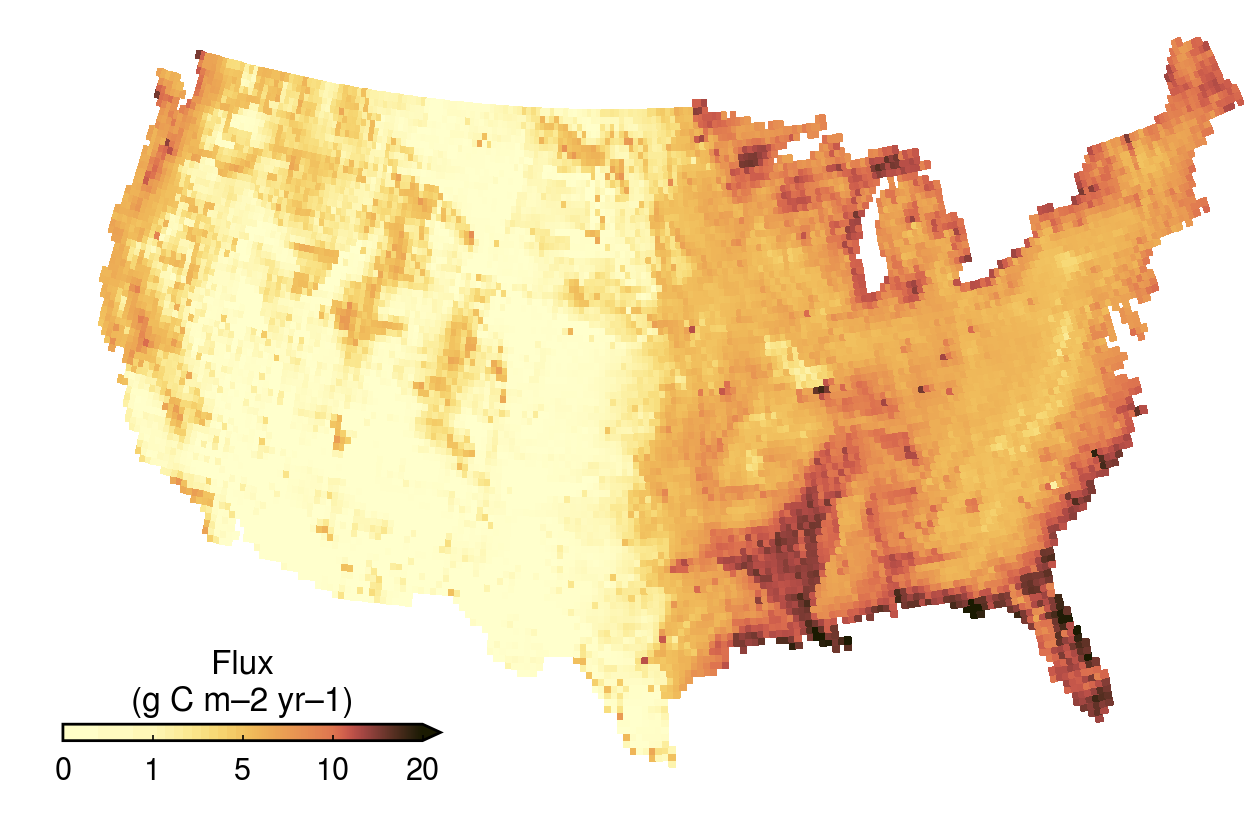

In [9]:
# grid-scale TOC flux map
def plot_grid_toc_flux(df_grid):
    df_pivot = df_grid.pivot(index='latitude', columns='longitude', values='F_TOC')
    da = xr.DataArray(df_pivot.values,
                      coords={"latitude": df_pivot.index.values, 
                              "longitude": df_pivot.columns.values},
                      dims=["latitude", "longitude"])
    coordination1 = 2163
    lonlim = (-122, -75)
    latlim = (25, 50)

    fig = uplt.figure(refwidth=6, share=False, span=False, tight=True)
    ax = fig.add_subplot(projection=ccrs.epsg(coordination1))

    cbar_tick = [0, 1, 5, 10, 20]
    norm = CustomNormalize(cbar_tick, np.linspace(0, 1, len(cbar_tick)))
    im = ax.pcolormesh(da.longitude,da.latitude,da.values,cmap='lajolla',discrete=False,norm=norm)

    cax = fig.add_axes([0.05, 0.1, 0.3, 0.02], title='Flux\n(g C m–2 yr–1)')
    fig.colorbar(im,cax=cax,orientation='horizontal',extend='max',ticks=cbar_tick)

    ax.format(lonlim=lonlim, latlim=latlim, linewidth=0)
    
plot_grid_toc_flux(grid_mean)

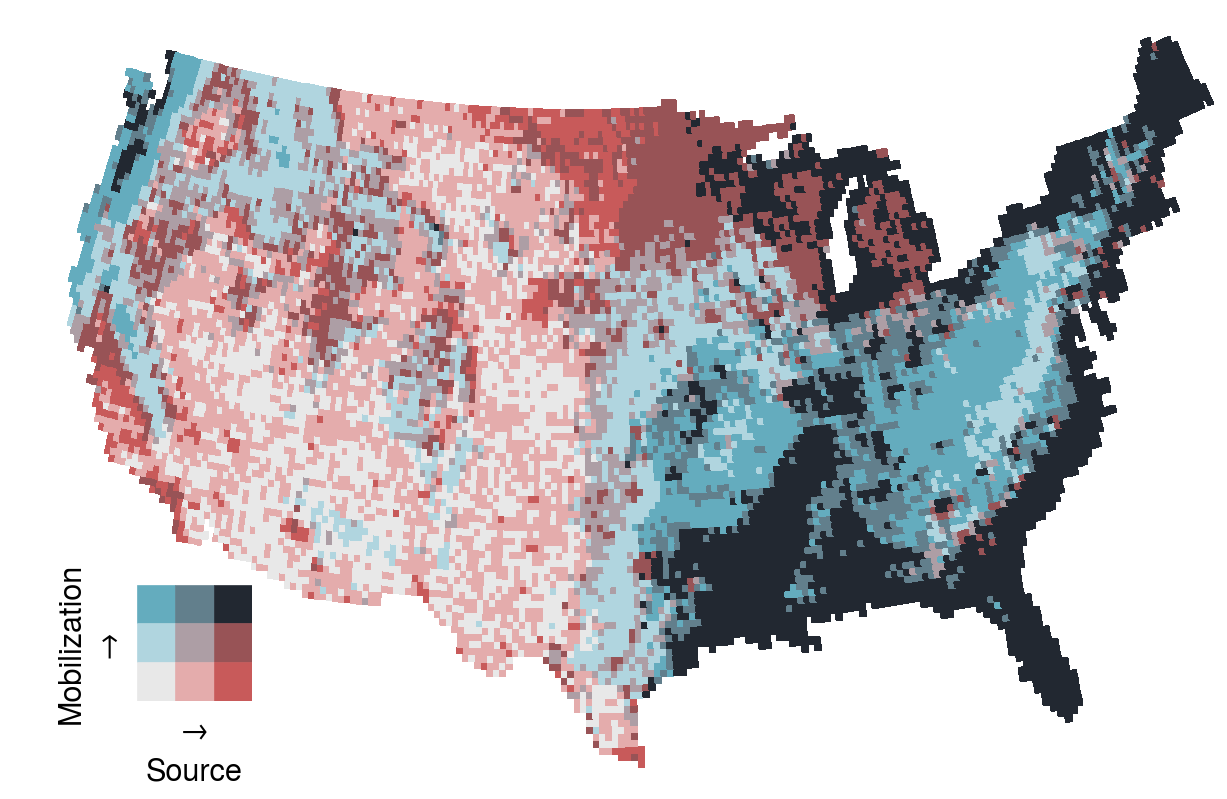

In [10]:
# grid-scale dual contribution (hydrological mobilization vs. source availability) map
def plot_grid_dual_contribution(df_grid):
    df = df_grid.copy()
    df = df[['latitude','longitude','c_source','c_mobilization']]
    df = df.dropna()   # some grid was not included in XAI modeling, as they have NaN values in some input variables
    
    # set color
    biv_cmap_list = [
        '#64acbe','#627f8c','#222831',
        '#b0d5df','#ad9ea5','#985356',
        '#e8e8e8','#e4acac','#c85a5a'
    ]
    biv_cmap = ListedColormap(biv_cmap_list)
    bivariate_map = np.array(biv_cmap_list).reshape(3, 3)

    # equally partition the two variables into quantiles (33.3%, 66.7%).
    bin_need = 3
    range_need= np.linspace(0, 1, bin_need+1)
    source_quantiles = df['c_source'].quantile(range_need).values   #_norm
    mobil_quantiles = df['c_mobilization'].quantile(range_need).values 

    # set bins
    df['source_bin'] = pd.cut(df['c_source'], bins=source_quantiles, labels=list(range(bin_need)), include_lowest=True)
    df['mobil_bin'] = pd.cut(df['c_mobilization'], bins=mobil_quantiles, labels=list(range(bin_need)), include_lowest=True)
    norm = BoundaryNorm(boundaries=range(bin_need*bin_need+1), ncolors=bin_need*bin_need)

    # build bivariate composite indexes (0–8)
    df['bivar_class'] = (bin_need-1-df['mobil_bin'].astype(int)) * bin_need + df['source_bin'].astype(int)
    
    df_pivot = df.pivot(index='latitude', columns='longitude', values='bivar_class')
    df_pivot = df_pivot.sort_index(ascending=True)
    da = xr.DataArray(df_pivot.values,
                      coords={"latitude": df_pivot.index.values, "longitude": df_pivot.columns.values},
                      dims=["latitude", "longitude"])
    
    coordination1 = 2163
    lonlim = (-122, -75)
    latlim = (25, 50)

    fig = uplt.figure(refwidth=6, share=False, span=False, tight=True)
    ax = fig.add_subplot(projection=ccrs.epsg(coordination1))

    im = ax.pcolormesh(da.longitude,da.latitude,da.values,cmap=biv_cmap,norm=norm)

    # create legend
    axins = inset_axes(ax,bbox_to_anchor=(0.05, 0.07, 0.75, 0.75),
                       bbox_transform=ax.transAxes, width="20%", height="20%", loc="lower left", borderpad=1)
    
    for i in range(bin_need):         
        for j in range(bin_need):    
            axins.add_patch(mpatches.Rectangle((j, bin_need-1-i), 1, 1, color=bivariate_map[i, j]))
    
    axins.set_xticks([])
    axins.set_yticks([])
    
    axins.set_xticks([(0+bin_need)/2])
    axins.set_xticklabels(['→'])
    axins.set_yticks([(0+bin_need)/2])
    axins.set_yticklabels(['↑'])
    
    axins.set_xlabel('Source')
    axins.set_ylabel('Mobilization')
    
    axins.set_xlim(0, bin_need)
    axins.set_ylim(0, bin_need)
    axins.tick_params(length=0)
    axins.set_aspect('equal')
    axins.spines[:].set_visible(False)

    ax.format(lonlim=lonlim, latlim=latlim, linewidth=0)
    
plot_grid_dual_contribution(grid_mean)

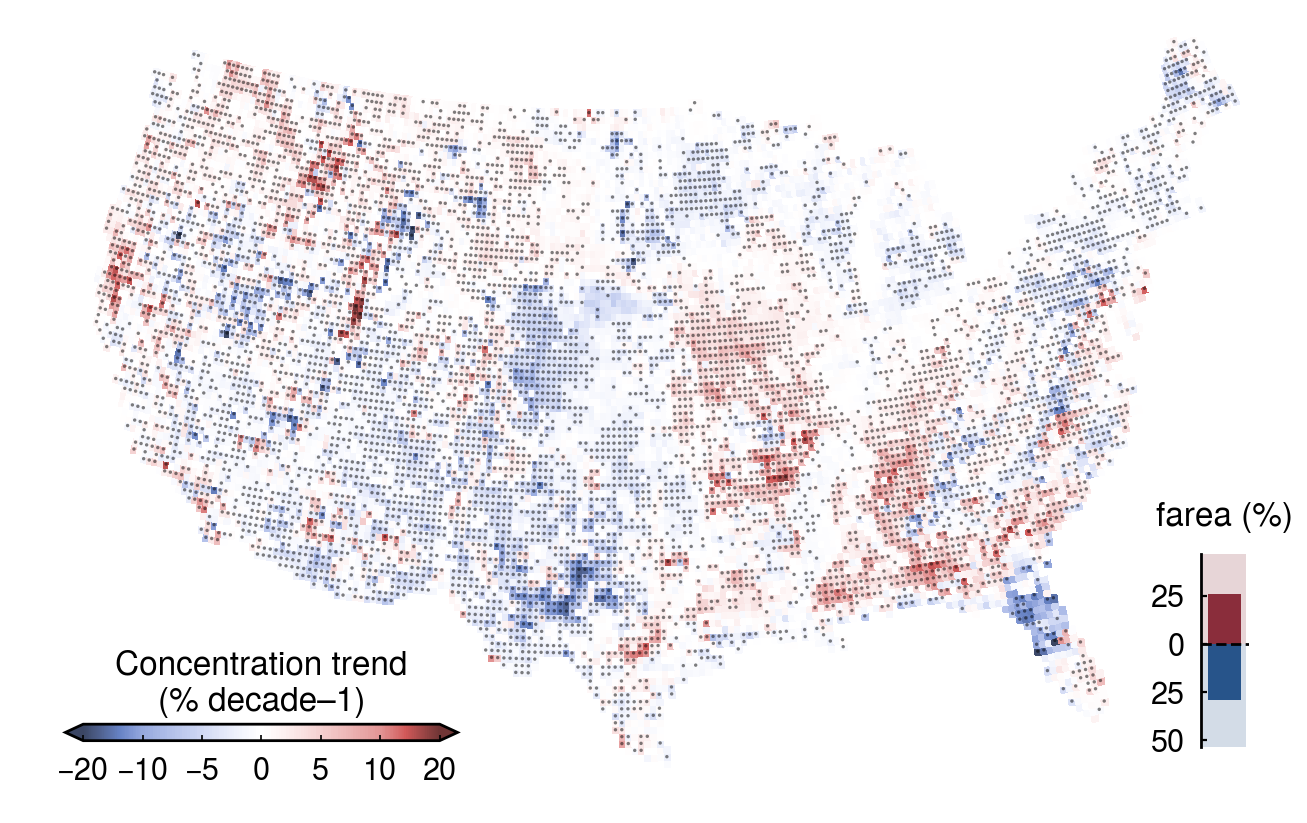

In [11]:
# grid-scale relative trend maps
# inset area proportion plot
def plot_trend_bar(df_grid, parent_ax,bbox_to_anchor,cmapi,width="20%", height="50%",size=1.0):
    df = df_grid.copy()
    inset_ax = inset_axes(parent_ax,
                          width=width,
                          height=height,
                          axes_kwargs={'zorder': 10},  
                          bbox_to_anchor=bbox_to_anchor,
                          bbox_transform=parent_ax.transAxes) 

    # use area-weighted
    total_area = df['area'].sum()

    conditions = [
        (df["Trend"] > 0) & (df["p"] >= 0.05),
        (df["Trend"] > 0) & (df["p"] < 0.05),
        (df["Trend"] < 0) & (df["p"] >= 0.05),
        (df["Trend"] < 0) & (df["p"] < 0.05)
    ]
    
    choices = ["increase", "sig. increase","decrease", "sig. decrease"]
    
    df["trend"] = np.select(conditions, choices, default="")

    # trend increase ( sig. increase and increase)
    inc_total = df.loc[df['trend'].isin(['sig. increase', 'increase']), 'area'].sum() / total_area * 100
    
    #  trend decrease ( sig. decrease and decrease)
    dec_total = df.loc[df['trend'].isin(['sig. decrease', 'decrease']), 'area'].sum() / total_area * 100
    
    # sig. increase
    sig_inc = df.loc[df['trend'] == 'sig. increase', 'area'].sum() / total_area * 100
    
    # sig. decrease
    sig_dec = df.loc[df['trend'] == 'sig. decrease', 'area'].sum() / total_area * 100
    
    categories = ['']
    inc_values = [inc_total]
    dec_values = [-dec_total]
    sig_inc_values = [sig_inc]
    sig_dec_values = [-sig_dec]

    w1 = 0.4 * size
    w2 = 0.3 * size
    positive_c = '#8A2D3B'  
    negative_c = '#27548A'  
    
    inset_ax.bar(categories, inc_values, width=w1, facecolor=positive_c,edgecolor='none', alpha=0.2, zorder=1)
    inset_ax.bar(categories, dec_values, width=w1, facecolor=negative_c, edgecolor='none',alpha=0.2, zorder=1)
    bar_sig_inc = inset_ax.bar(categories, sig_inc_values, width=w2, facecolor=positive_c,edgecolor='none', alpha=1, zorder=2)
    bar_sig_dec = inset_ax.bar(categories, sig_dec_values, width=w2, facecolor=negative_c,edgecolor='none', alpha=1, zorder=2)


    inset_ax.axhline(0, color='black', linestyle='--', linewidth=1, zorder=3)

    inset_ax.set_yticks([-50,-25, 0, 25,50]) 
    inset_ax.set_yticklabels(['50','25', '0', '25', '50']) # ylabel
    inset_ax.set_ylim(-dec_total, inc_total)
    
    inset_ax.set_xticks([])
    inset_ax.set_xticklabels([])
    inset_ax.set_xlabel('')
    inset_ax.tick_params(axis='x', which='both', bottom=False, top=False)
    inset_ax.tick_params(axis='y', which='both', right=False)

    inset_ax.spines['left'].set_visible(True)
    inset_ax.spines['left'].set_color('black')
    inset_ax.spines['left'].set_linewidth(1)

    inset_ax.spines['right'].set_visible(False)
    inset_ax.spines['top'].set_visible(False)
    inset_ax.spines['bottom'].set_visible(False)

    inset_ax.set_title('farea (%)', pad=10)

def plot_grid_trend_concentration(df_grid):
    df = df_grid[['latitude','longitude','Trend_C_TOC','p_C_TOC','area']]
    df.columns = ['latitude','longitude','Trend','p','area']
    df_pivot = df.pivot(index='latitude', columns='longitude', values='Trend')
    da = xr.DataArray(df_pivot.values,
                      coords={"latitude": df_pivot.index.values, 
                              "longitude": df_pivot.columns.values},
                      dims=["latitude", "longitude"])
    coordination1 = 2163
    lonlim = (-122, -75)
    latlim = (25, 50)

    fig = uplt.figure(refwidth=6, share=False, span=False, tight=True)
    ax = fig.add_subplot(projection=ccrs.epsg(coordination1))

    cbar_tick = [-20,-10,-5,0,5,10,20]
    norm = CustomNormalize(cbar_tick, np.linspace(0, 1, len(cbar_tick)))
    im = ax.pcolormesh(da.longitude,da.latitude,da.values,cmap='Div',discrete=False,norm=norm)

    # grid with p<0.05
    grid_sig = df[df['p'] < 0.05]
    ax.scatter(grid_sig['longitude'],grid_sig['latitude'],lw=0,edgecolor='none',facecolor='k',s=1.5,alpha=0.5,
               transform=ccrs.PlateCarree(),zorder=88)


    cax = fig.add_axes([0.05, 0.1, 0.3, 0.02], title='Concentration trend\n(% decade–1)')
    fig.colorbar(im,cax=cax,orientation='horizontal',extend='both',ticks=cbar_tick)


    # inset area proportion plot
    plot_trend_bar(df, parent_ax=ax, bbox_to_anchor=(0.82, -0.18, 0.2, 0.5),cmapi=im.cmap)

    ax.format(lonlim=lonlim, latlim=latlim, linewidth=0)
    
plot_grid_trend_concentration(grid_mean)

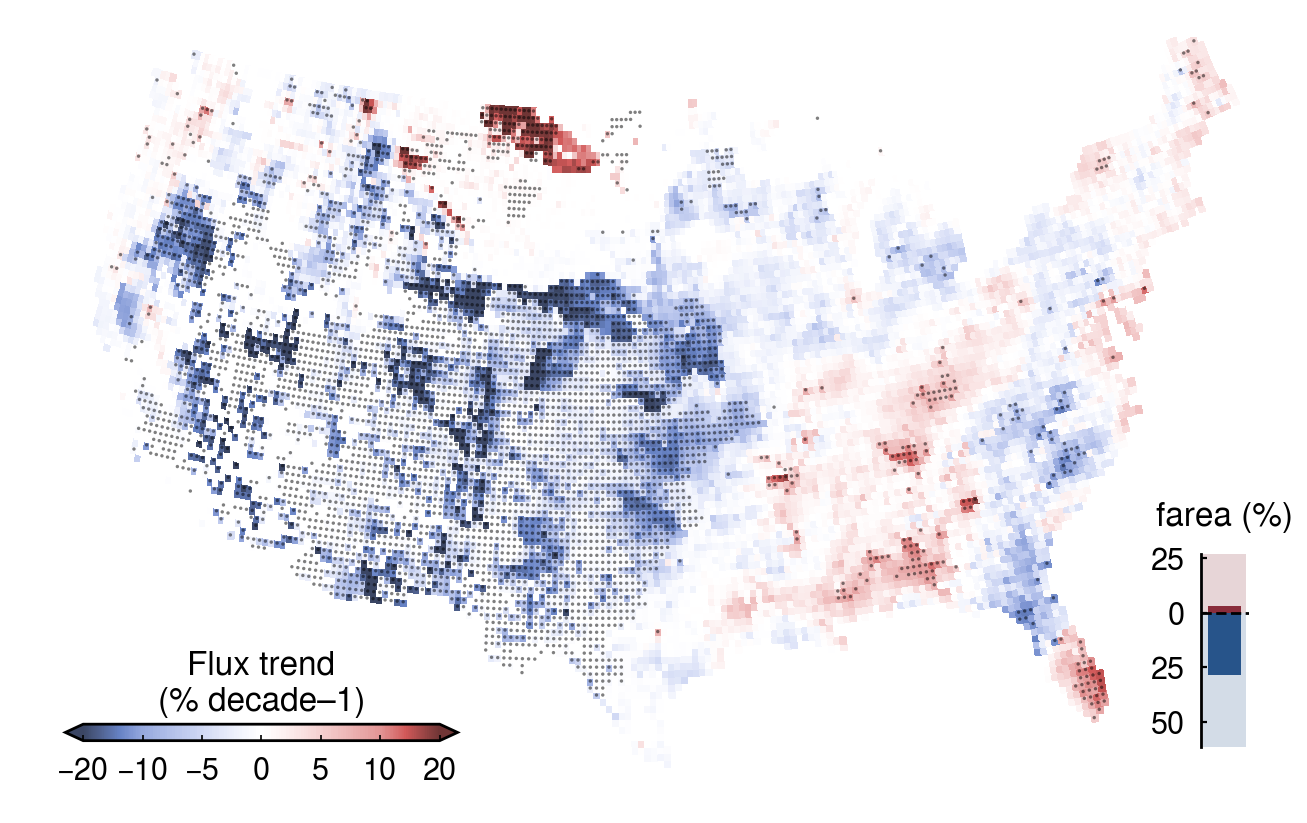

In [12]:
def plot_grid_trend_flux(df_grid):
    df = df_grid[['latitude','longitude','Trend_F_TOC','p_F_TOC','area']]
    df.columns = ['latitude','longitude','Trend','p','area']
    df_pivot = df.pivot(index='latitude', columns='longitude', values='Trend')
    da = xr.DataArray(df_pivot.values,
                      coords={"latitude": df_pivot.index.values, 
                              "longitude": df_pivot.columns.values},
                      dims=["latitude", "longitude"])
    coordination1 = 2163
    lonlim = (-122, -75)
    latlim = (25, 50)

    fig = uplt.figure(refwidth=6, share=False, span=False, tight=True)
    ax = fig.add_subplot(projection=ccrs.epsg(coordination1))

    cbar_tick = [-20,-10,-5,0,5,10,20]
    norm = CustomNormalize(cbar_tick, np.linspace(0, 1, len(cbar_tick)))
    im = ax.pcolormesh(da.longitude,da.latitude,da.values,cmap='Div',discrete=False,norm=norm)

    # grid with p<0.05
    grid_sig = df[df['p'] < 0.05]
    ax.scatter(grid_sig['longitude'],grid_sig['latitude'],lw=0,edgecolor='none',facecolor='k',s=1.5,alpha=0.5,
               transform=ccrs.PlateCarree(),zorder=88)


    cax = fig.add_axes([0.05, 0.1, 0.3, 0.02], title='Flux trend\n(% decade–1)')
    fig.colorbar(im,cax=cax,orientation='horizontal',extend='both',ticks=cbar_tick)


    # inset area proportion plot
    plot_trend_bar(df, parent_ax=ax, bbox_to_anchor=(0.82, -0.18, 0.2, 0.5),cmapi=im.cmap)

    ax.format(lonlim=lonlim, latlim=latlim, linewidth=0)
    
plot_grid_trend_flux(grid_mean)

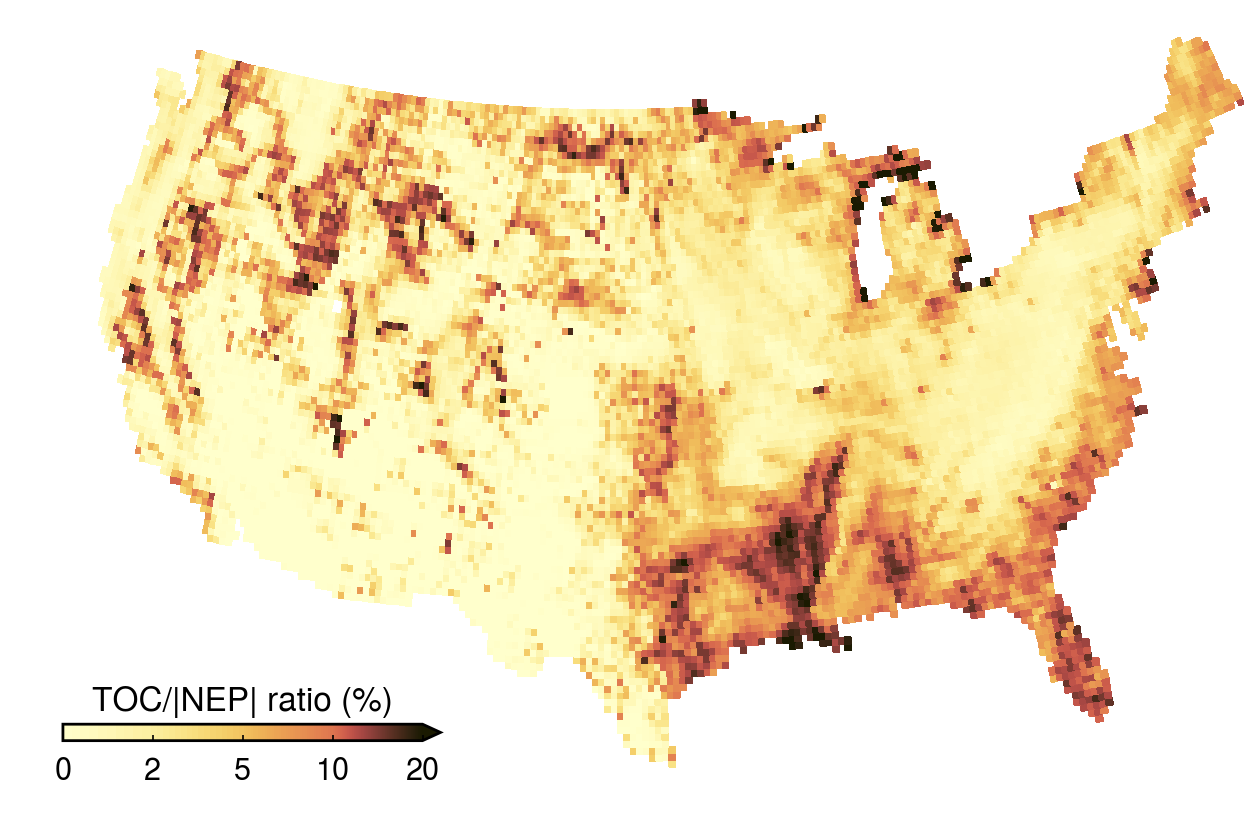

In [13]:
# grid-scale TOC/|NEP| ratio map
def plot_grid_toc_nep_ratio(df_grid):
    df_pivot = df_grid.pivot(index='latitude', columns='longitude', values='TOC/|NEP| ratio') 
    da = xr.DataArray(df_pivot.values,
                      coords={"latitude": df_pivot.index.values, "longitude": df_pivot.columns.values},
                      dims=["latitude", "longitude"])
    
    coordination1 = 2163
    lonlim = (-122, -75)
    latlim = (25, 50)
    
    fig = uplt.figure(refwidth=6, share=False, span=False, tight=True)
    ax = fig.add_subplot(projection=ccrs.epsg(coordination1))
    
    cbar_tick = [0,2,5,10,20]  
    norm = CustomNormalize(cbar_tick, np.linspace(0, 1, len(cbar_tick)))
    im = ax.pcolormesh(da.longitude,da.latitude,da.values,cmap='lajolla',discrete=False,norm=norm)
    
    # colorbar
    cax = fig.add_axes([0.05, 0.1, 0.3, 0.02], title='TOC/|NEP| ratio (%)')
    fig.colorbar(im,cax=cax,orientation='horizontal',extend='max',ticks=cbar_tick)
    
    
    ax.format(lonlim=lonlim, latlim=latlim, linewidth=0)

plot_grid_toc_nep_ratio(grid_mean)